In [28]:
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import numpy as np
from single_qubit_pyscrip_v1_1 import system_cfg
from single_qubit_pyscrip_v1_1.system_tool import select_config_idx
from qick.asm_v2 import QickSpan, QickSweep1D
soc, soccfg = system_cfg.soc, system_cfg.soccfg


QICK library version mismatch: 0.2.302 remote (the board), 0.2.325 local (the PC)
                        This may cause errors, usually KeyError in QickConfig initialization.
                        If this happens, you must bring your versions in sync.


Pyro.NameServer PYRO:Pyro.NameServer@0.0.0.0:8888
myqick PYRO:obj_1e50e4b7d3dd4580b4acdd800bad7916@192.168.10.212:37061
QICK running on ZCU216, software version 0.2.302

Firmware configuration (built Tue Sep 10 16:13:40 2024):

	Global clocks (MHz): tProcessor 430.080, RF reference 245.760

	16 signal generator channels:
	0:	axis_signal_gen_v6 - envelope memory 16384 samples (1.709 us)
		fs=9584.640 MHz, fabric=599.040 MHz, 32-bit DDS, range=9584.640 MHz
		DAC tile 2, blk 0 is 0_230, on JHC3
	1:	axis_signal_gen_v6 - envelope memory 4096 samples (0.427 us)
		fs=9584.640 MHz, fabric=599.040 MHz, 32-bit DDS, range=9584.640 MHz
		DAC tile 2, blk 1 is 1_230, on JHC4
	2:	axis_signal_gen_v6 - envelope memory 8192 samples (0.855 us)
		fs=9584.640 MHz, fabric=599.040 MHz, 32-bit DDS, range=9584.640 MHz
		DAC tile 2, blk 2 is 2_230, on JHC3
	3:	axis_signal_gen_v6 - envelope memory 4096 samples (0.427 us)
		fs=9584.640 MHz, fabric=599.040 MHz, 32-bit DDS, range=9584.640 MHz
		DAC tile 2, blk 3 is

In [29]:
config={**system_cfg.hw_cfg,**system_cfg.readout_cfg, **system_cfg.qubit_cfg, **system_cfg.expt_cfg}
qubit_idx=3
run_cfg = select_config_idx(config, qubit_idx)

# TOF

  0%|          | 0/2000 [00:00<?, ?it/s]

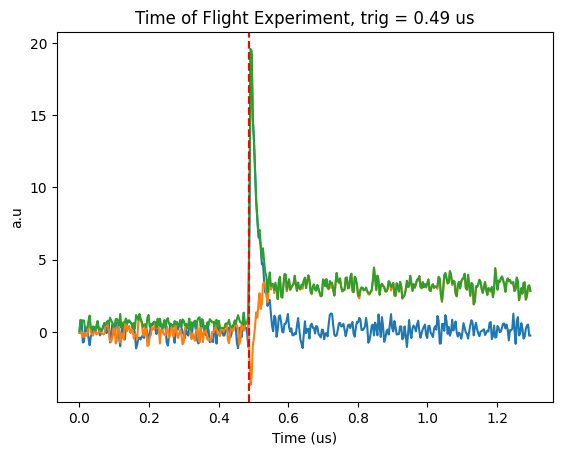

In [6]:
from single_qubit_pyscrip_v1_1.s001_time_of_flight import TOF

run_cfg = select_config_idx(config, qubit_idx)
run_cfg.update({
    'ro_length':1.3,
    'res_legnth':0.2,
    'res_gain_ge':1
})

tof = TOF(soc, soccfg, run_cfg)
tof.run()
tof.plot()

config['trig_time']=0.49

# Resonator OneTone

Data save to C:\Users\QEL\Desktop\2DQ12\test\2025\05\Data_0528\s002_onetone_Q3_2


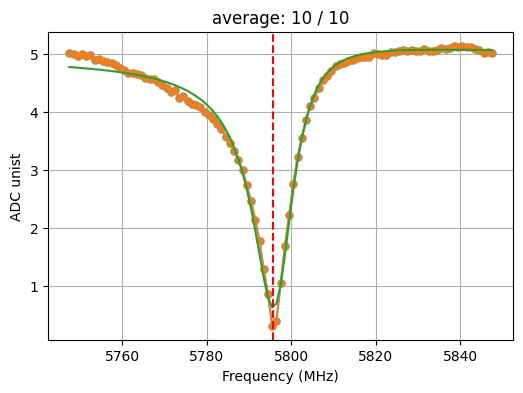

In [31]:
from single_qubit_pyscrip_v1_1.s002_res_spec_ge import Resonator_onetone

run_cfg = select_config_idx(config, qubit_idx)

START_FREQ = config['res_freq_ge'][qubit_idx]- 50  # [MHz]
STOP_FREQ = config['res_freq_ge'][qubit_idx] + 50   # [MHz]
STEPS = 101
run_cfg.update([('steps', STEPS), 
                ('res_freq_ge', QickSweep1D('freqloop', START_FREQ, STOP_FREQ)),
                ('res_gain_ge',0.2)
                ])

onetone = Resonator_onetone(soc, soccfg, run_cfg)
# onetone.run(py_avg=10)
fres = onetone.run(py_avg=10, liveplot=True)
# result = onetone.plot_circle()
## update value ##
config['res_freq_ge'][qubit_idx] = fres
onetone.saveLabber(qubit_idx, save_sim=True)

Data save to C:\Users\QEL\Desktop\2DQ12\test\2025\05\Data_0528\002b_res_ge_punchout_Q3_2


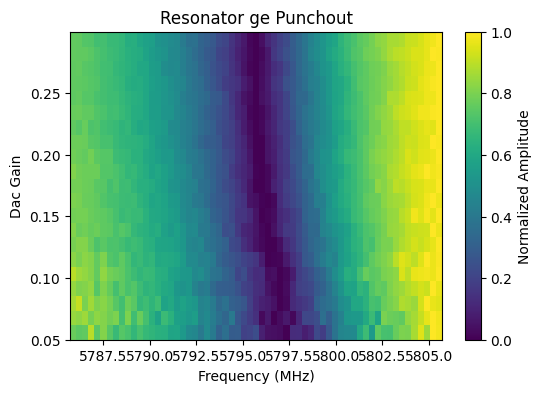

In [51]:
from single_qubit_pyscrip_v1_1.s002b_res_punchout_ge import SingleToneSpectroscopyPunchout

run_cfg = select_config_idx(config, qubit_idx)

START_FREQ = config['res_freq_ge'][qubit_idx]- 10  # [MHz]
STOP_FREQ = config['res_freq_ge'][qubit_idx] + 10   # [MHz]
STEPS_freq = 61

START_gain = 0.05  # [MHz]
STOP_gain = 0.3  # [MHz]
STEPS_gain = 21
run_cfg.update([('f_steps', STEPS_freq), ('res_freq_ge', QickSweep1D('freqloop', START_FREQ, STOP_FREQ)),
               ('g_steps', STEPS_gain), ('res_gain_ge', QickSweep1D('gainloop', START_gain, STOP_gain))])
punchout = SingleToneSpectroscopyPunchout(soc, soccfg, run_cfg)
punchout.run(py_avg=2, liveplot=True)
punchout.saveLabber(qubit_idx)

# Qubit Spectrum ge

Data save to C:\Users\QEL\Desktop\2DQ12\test\2025\05\Data_0528\003_qubit_spec_ge_Q3_3


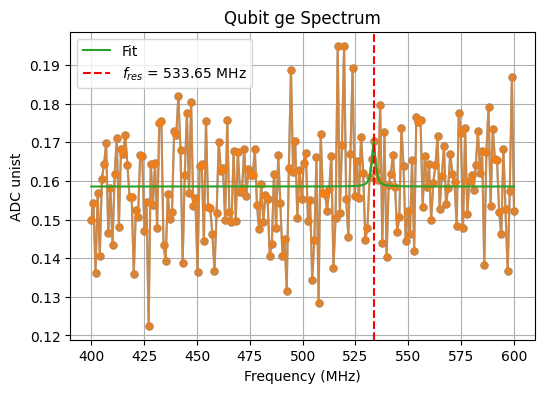

In [10]:
from single_qubit_pyscrip_v1_1.s003_qubit_spec_ge import Qubit_Twotone

run_cfg = select_config_idx(config, qubit_idx)

cemter = 500
SPAN = 100
START_FREQ = cemter - SPAN # [MHz]
STOP_FREQ = cemter + SPAN  # [MHz]
STEPS = 200
run_cfg.update([('steps', STEPS), 
                ('qubit_freq_ge', QickSweep1D('freqloop', START_FREQ, STOP_FREQ)),
                ('qmixer_freq',cemter),
                ('qubit_gain_ge', 0.3),
                ('relax_delay',1)
                ])

spectrum_ge = Qubit_Twotone(soc, soccfg, run_cfg)
f_ge = spectrum_ge.run(20, liveplot=True)
# f_ge = spectrum_ge.plot()
config['qubit_freq_ge'][qubit_idx] = f_ge
config['qmixer_freq'][qubit_idx] = f_ge
spectrum_ge.saveLabber(qubit_idx, save_sim=True)

Data save to C:\Users\QEL\Desktop\2DQ12\test\2025\05\Data_0528\005_power_rabi_ge_Q0_7


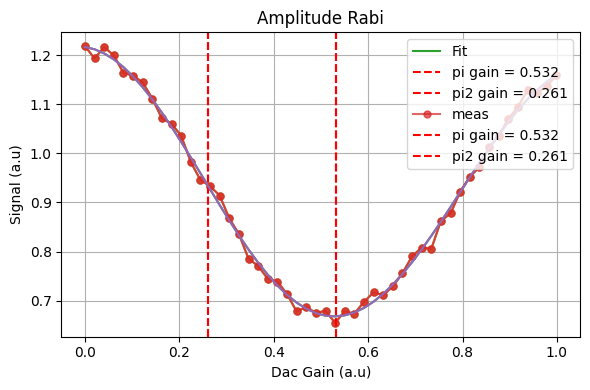

In [ ]:
from single_qubit_pyscrip_v1_1.s005_power_rabi_ge import Amp_Rabi


START_GAIN = 0.0  # [DAC units]
STOP_GAIN = 1  # [DAC units]
STEPS = 50
config["sigma"][qubit_idx] = 0.3
config['relax_delay'] = 50
run_cfg = select_config_idx(config, qubit_idx)
run_cfg.update([
    ('steps', STEPS), 
    ('qubit_gain_ge',QickSweep1D('gainloop', START_GAIN, STOP_GAIN)),
    ])

prabi = Amp_Rabi(soc, soccfg, run_cfg)
prabi.run(50, liveplot=True)
config['qubit_pi_gain_ge'][qubit_idx], config['qubit_pi2_gain_ge'][qubit_idx] = prabi.plot()
prabi.saveLabber(qubit_idx)

# Ramsey

over detune -0.00838MHz
Data save to C:\Users\QEL\Desktop\2DQ12\test\2025\05\Data_0528\006_Ramsey_ge_Q0_0mA


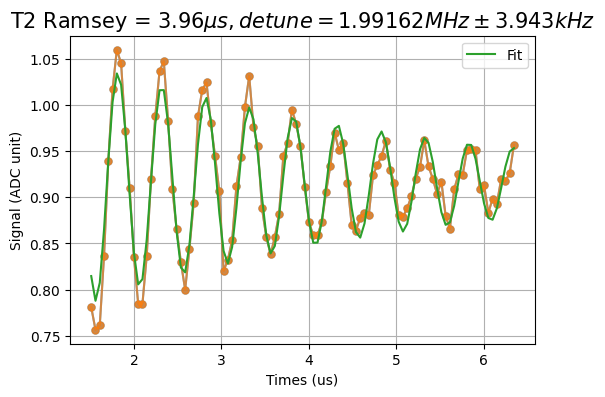

In [ ]:
from single_qubit_pyscrip_v1_1.s006_Ramsey_ge import Ramsey

run_cfg = select_config_idx(config, qubit_idx)

START_TIME = 0.0  # [us]
STOP_TIME = 5  # [us]
STEPS = 100
run_cfg.update([
    ('steps', STEPS), 
    ('wait_time',QickSweep1D('waitloop', START_TIME, STOP_TIME)),
    ('ramsey_freq',2)
    ])

t2r = Ramsey(soc, soccfg, run_cfg)
t2r.run(50, liveplot=True)
# t2r.plot()
config['qubit_freq_ge'][qubit_idx] = t2r.correct_detune()
t2r.saveLabber(qubit_idx, 0, save_sim=True)


Data save to C:\Users\QEL\Desktop\2DQ12\test\2025\05\Data_0528\s007_SpinEcho_ge_Q0_0mA


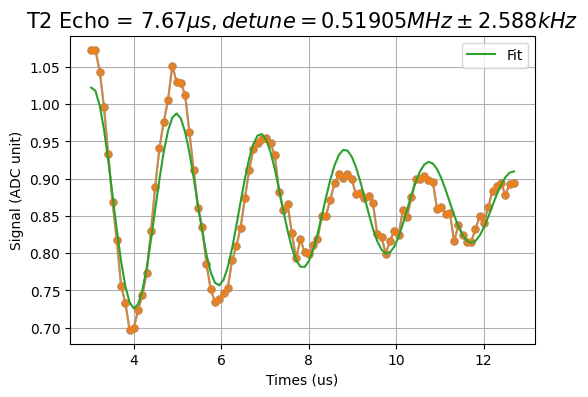

In [ ]:
from single_qubit_pyscrip_v1_1.s007_SpinEcho_ge import SpinEcho

run_cfg = select_config_idx(config, qubit_idx)

START_TIME = 0.0  # [us]
STOP_TIME = 10  # [us]
STEPS = 100
run_cfg.update([
    ('steps', STEPS), 
    ('wait_time',QickSweep1D('waitloop', START_TIME, STOP_TIME)),
    ('ramsey_freq',0.5)
    ])

t2e = SpinEcho(soc, soccfg, run_cfg)
t2e.run(50, liveplot=True)
# t2r.plot()

t2e.saveLabber(qubit_idx, 0, save_sim=True)

# T1

Data save to C:\Users\QEL\Desktop\2DQ12\test\2025\05\Data_0528\s008_T1_ge_Q0_0mA


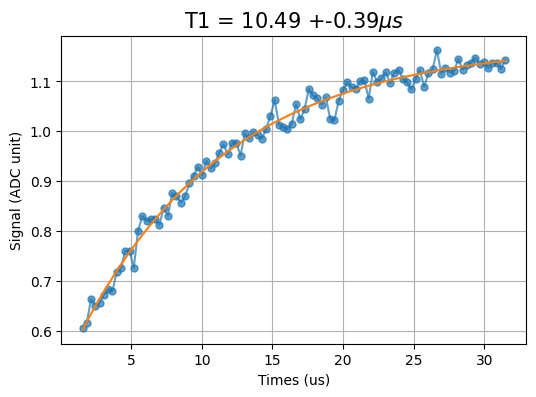

In [ ]:
from single_qubit_pyscrip_v1_1.s008_T1_ge import T1

run_cfg = select_config_idx(config, qubit_idx)

START_TIME = 0.0  # [us]
STOP_TIME = 30  # [us]
STEPS = 100
run_cfg.update([
    ('steps', STEPS), 
    ('wait_time',QickSweep1D('waitloop', START_TIME, STOP_TIME)),
    ('relax_delay', 50)
    ])

t1 = T1(soc, soccfg, run_cfg)
t1.run(20, liveplot=True)


t1.saveLabber(qubit_idx, 0, save_sim=True)